In [244]:
import pandas as pd

path = r"D:\数据\qfq_15min_all.csv"

df = pd.read_csv(path)

print("shape:", df.shape)
print("columns:", df.columns.tolist())
df


shape: (1542021, 47)
columns: ['SecuCode', 'TradingDay', 'TimeStart', 'TimeEnd', 'TimeInterval', 'DealNum_sum', 'Volume_sum', 'Turnover_sum', 'TotalDealNum_last', 'TotalVolume_last', 'TotalTurnover_last', 'TotalBidVolume_last', 'TotalAskVolume_last', 'WeightBidPrice_last', 'WeightAskPrice_last', 'AskPrice1_last', 'AskVolume1_last', 'AskPrice2_last', 'AskVolume2_last', 'AskPrice3_last', 'AskVolume3_last', 'AskPrice4_last', 'AskVolume4_last', 'BidPrice1_last', 'BidVolume1_last', 'BidPrice2_last', 'BidVolume2_last', 'BidPrice3_last', 'BidVolume3_last', 'BidPrice4_last', 'BidVolume4_last', 'BidOrder1_last', 'BidOrder2_last', 'BidOrder3_last', 'BidOrder4_last', 'AskOrder1_last', 'AskOrder2_last', 'AskOrder3_last', 'AskOrder4_last', 'TickTimeDiff_mean', 'OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice', 'TickCount', 'VWAP', 'dTotalVolume']


,SecuCode,TradingDay,TimeStart,TimeEnd,TimeInterval,DealNum_sum,Volume_sum,Turnover_sum,TotalDealNum_last,TotalVolume_last,...,AskOrder3_last,AskOrder4_last,TickTimeDiff_mean,OpenPrice,HighPrice,LowPrice,ClosePrice,TickCount,VWAP,dTotalVolume
0,400,20180102,930,945,09:30-09:45,716.0,859900.0,11327554.0,730.0,871300.0,...,0.0,0.0,3.289655,12.372764,12.372764,12.288532,12.288532,290,12.328875,859900.0
1,400,20180102,945,1000,09:45-10:00,629.0,934320.0,12278859.0,1359.0,1805620.0,...,0.0,0.0,3.169014,12.288532,12.363405,12.269813,12.307250,284,12.299788,929320.0
2,400,20180102,1000,1015,10:00-10:15,603.0,795250.0,10453716.0,1962.0,2600870.0,...,0.0,0.0,3.321033,12.297891,12.354045,12.260454,12.335327,271,12.302753,777350.0
3,400,20180102,1015,1030,10:15-10:30,602.0,522968.0,6907255.5,2564.0,3123838.0,...,0.0,0.0,3.146853,12.344686,12.382123,12.335327,12.354045,286,12.361344,522068.0
4,400,20180102,1030,1045,10:30-10:45,480.0,397000.0,5234533.0,3044.0,3520838.0,...,0.0,0.0,3.529412,12.354045,12.354045,12.325968,12.344686,255,12.340214,393100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1542016,603000,20251231,1345,1400,13:45-14:00,442.0,208600.0,3981415.0,11495.0,7025820.0,...,32.0,11.0,3.214286,19.090000,19.100000,19.070000,19.070000,280,19.086361,208500.0
1542017,603000,20251231,1400,1415,14:00-14:15,458.0,234000.0,4466044.0,11953.0,7259820.0,...,13.0,23.0,3.092784,19.080000,19.100000,19.070000,19.090000,291,19.085659,229300.0
1542018,603000,20251231,1415,1430,14:15-14:30,385.0,262700.0,5011655.0,12338.0,7522520.0,...,47.0,16.0,3.135889,19.090000,19.090000,19.070000,19.070000,287,19.077484,262600.0
1542019,603000,20251231,1430,1445,14:30-14:45,820.0,497000.0,9476143.0,13158.0,8019520.0,...,55.0,16.0,3.114187,19.070000,19.080000,19.060000,19.070000,289,19.066687,496800.0


In [11]:
import importlib
import factor_eval_old
importlib.reload(factor_eval_old)
from factor_eval_old import fast_factor_eval_from_long_df

In [247]:
cols_to_drop = [
    'TickTimeDiff_mean',
    'TickCount'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [248]:
import numpy as np
import pandas as pd

# =========================================================
# 0) 排序（非常关键：确保shift(-1)就是下一根bar）
# =========================================================
sort_cols = [c for c in ['SecuCode', 'TradingDay', 'TimeStart', 'TimeEnd', 'TickTime'] if c in df.columns]
if not sort_cols:
    raise ValueError("df里需要能排序的列，比如 SecuCode/TradingDay/TimeStart(TimeEnd) 或 TickTime.")

df = df.sort_values(sort_cols).reset_index(drop=True)

# 分组：通常bar数据用 (SecuCode, TradingDay)，tick也一样
g = df.groupby(['SecuCode', 'TradingDay'], sort=False)

# =========================================================
# 1) mid / spread / microprice / book_state（去重：mid只算一次）
# =========================================================
bid1 = df['BidPrice1_last']
ask1 = df['AskPrice1_last']
bv1  = df['BidVolume1_last'] if 'BidVolume1_last' in df.columns else np.nan
av1  = df['AskVolume1_last'] if 'AskVolume1_last' in df.columns else np.nan

# mid: 双边 -> 均值；单边 -> 非0那一侧；都0 -> NaN
df['mid'] = np.where(
    (bid1 > 0) & (ask1 > 0),
    0.5 * (bid1 + ask1),
    np.where(bid1 > 0, bid1, np.where(ask1 > 0, ask1, np.nan))
)

tick = 0.01  # 根据市场设置

df['spread'] = np.where(
    (bid1 > 0) & (ask1 > 0),
    ask1 - bid1,
    tick
)

# microprice：双边且量有效才算；否则退化为 mid
den = (bv1 + av1)
df['microprice'] = np.where(
    (bid1 > 0) & (ask1 > 0) & (den > 0),
    (ask1 * bv1 + bid1 * av1) / den,
    df['mid']
)

df['microprice_minus_mid'] = df['microprice'] - df['mid']

# 盘口状态：0=双边正常，1=仅bid，2=仅ask，NaN=都没
df['book_state'] = np.select(
    [
        (bid1 > 0) & (ask1 > 0),
        (bid1 > 0) & (ask1 <= 0),
        (bid1 <= 0) & (ask1 > 0),
    ],
    [0, 1, 2],
    default=np.nan
)






In [249]:
import numpy as np

df = df.sort_values(["SecuCode", "TradingDay", "TimeEnd", "TimeStart"]).reset_index(drop=True)

g = df.groupby("SecuCode", sort=False)

df["log_mid_ret_t1"] = np.log(g["mid"].shift(-1)) - np.log(df["mid"])

In [250]:
df = df.sort_values(["SecuCode", "TradingDay", "TimeEnd", "TimeStart"]).reset_index(drop=True)

g = df.groupby("SecuCode", sort=False)

df["ret_mid_t1"] = g["mid"].shift(-1) / df["mid"] - 1.0

In [251]:
import numpy as np
import pandas as pd
import importlib
import Factor
importlib.reload(Factor)

<module 'Factor' from 'C:\\Users\\Zack66Fair\\Factor.py'>

In [252]:
print("columns:", df.columns.tolist())

columns: ['SecuCode', 'TradingDay', 'TimeStart', 'TimeEnd', 'TimeInterval', 'DealNum_sum', 'Volume_sum', 'Turnover_sum', 'TotalDealNum_last', 'TotalVolume_last', 'TotalTurnover_last', 'TotalBidVolume_last', 'TotalAskVolume_last', 'WeightBidPrice_last', 'WeightAskPrice_last', 'AskPrice1_last', 'AskVolume1_last', 'AskPrice2_last', 'AskVolume2_last', 'AskPrice3_last', 'AskVolume3_last', 'AskPrice4_last', 'AskVolume4_last', 'BidPrice1_last', 'BidVolume1_last', 'BidPrice2_last', 'BidVolume2_last', 'BidPrice3_last', 'BidVolume3_last', 'BidPrice4_last', 'BidVolume4_last', 'BidOrder1_last', 'BidOrder2_last', 'BidOrder3_last', 'BidOrder4_last', 'AskOrder1_last', 'AskOrder2_last', 'AskOrder3_last', 'AskOrder4_last', 'OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice', 'VWAP', 'dTotalVolume', 'mid', 'spread', 'microprice', 'microprice_minus_mid', 'book_state', 'log_mid_ret_t1', 'ret_mid_t1']


In [253]:
df

,SecuCode,TradingDay,TimeStart,TimeEnd,TimeInterval,DealNum_sum,Volume_sum,Turnover_sum,TotalDealNum_last,TotalVolume_last,...,ClosePrice,VWAP,dTotalVolume,mid,spread,microprice,microprice_minus_mid,book_state,log_mid_ret_t1,ret_mid_t1
0,400,20180102,930,945,09:30-09:45,716.0,859900.0,11327554.0,730.0,871300.0,...,12.288532,12.328875,859900.0,12.293211,0.009359,12.294183,0.000972,0.0,0.000761,0.000761
1,400,20180102,945,1000,09:45-10:00,629.0,934320.0,12278859.0,1359.0,1805620.0,...,12.307250,12.299788,929320.0,12.302570,0.009359,12.304450,0.001880,0.0,0.003038,0.003043
2,400,20180102,1000,1015,10:00-10:15,603.0,795250.0,10453716.0,1962.0,2600870.0,...,12.335327,12.302753,777350.0,12.340007,0.009359,12.338679,-0.001328,0.0,0.001516,0.001517
3,400,20180102,1015,1030,10:15-10:30,602.0,522968.0,6907255.5,2564.0,3123838.0,...,12.354045,12.361344,522068.0,12.358725,0.009359,12.357219,-0.001506,0.0,-0.001895,-0.001893
4,400,20180102,1030,1045,10:30-10:45,480.0,397000.0,5234533.0,3044.0,3520838.0,...,12.344686,12.340214,393100.0,12.335327,0.018718,12.334389,-0.000938,0.0,0.003030,0.003035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1542016,603000,20251231,1345,1400,13:45-14:00,442.0,208600.0,3981415.0,11495.0,7025820.0,...,19.070000,19.086361,208500.0,19.075000,0.010000,19.075036,0.000036,0.0,0.000524,0.000524
1542017,603000,20251231,1400,1415,14:00-14:15,458.0,234000.0,4466044.0,11953.0,7259820.0,...,19.090000,19.085659,229300.0,19.085000,0.010000,19.084667,-0.000333,0.0,-0.000524,-0.000524
1542018,603000,20251231,1415,1430,14:15-14:30,385.0,262700.0,5011655.0,12338.0,7522520.0,...,19.070000,19.077484,262600.0,19.075000,0.010000,19.076215,0.001215,0.0,0.000000,0.000000
1542019,603000,20251231,1430,1445,14:30-14:45,820.0,497000.0,9476143.0,13158.0,8019520.0,...,19.070000,19.066687,496800.0,19.075000,0.010000,19.071603,-0.003397,0.0,-0.000787,-0.000786


In [254]:
import numpy as np
import pandas as pd
import inspect
import importlib
import Factor as F
importlib.reload(F)

# =========================
# 0) sort (保证与老df的label对齐)
# =========================
sort_cols = ["SecuCode","TradingDay","TimeEnd","TimeStart"]
df = df.sort_values(sort_cols).reset_index(drop=True)

# =========================
# 1) label: 用老df里已有的 log，不重算、不覆盖
#    同时补一个 arithmetic return: ret_mid_t1（若不存在才计算）
# =========================
log_y = "log_mid_ret_t1"
arith_y = "ret_mid_t1"

if log_y not in df.columns:
    raise ValueError(f"{log_y} not found in df. You said old df label is correct, so it must exist.")

# 只在 ret_mid_t1 不存在时计算；存在则不动
if arith_y not in df.columns:
    # 用同资产下一根bar的 mid 算 arithmetic return
    df = df.sort_values(["SecuCode","TradingDay","TimeEnd","TimeStart"]).reset_index(drop=True)
    g = df.groupby("SecuCode", sort=False)
    mid_next = g["mid"].shift(-1)
    df[arith_y] = (mid_next / df["mid"] - 1.0).astype("float32")

# （可选）一致性检查：log == log1p(arith)
# 注意：log_y 是老df里的，可能有你自己的特殊处理（比如跨日/停牌过滤），不一定100%一致
# check = np.allclose(df[log_y], np.log1p(df[arith_y]), equal_nan=True)
# print("log/arithmetic consistent:", check)

# =========================
# 2) dtype: key保持int64，其它数值float32
# =========================
key_cols = ["SecuCode","TradingDay","TimeStart","TimeEnd"]
for c in key_cols:
    df[c] = df[c].astype("int64")

num_cols = [c for c in df.select_dtypes(include=["number"]).columns if c not in key_cols]
df[num_cols] = df[num_cols].astype("float32")

# =========================
# 3) compute factors
# =========================
def compute_factors_001_070_fast(df, i=20, prefix="f_", j_default=4, k_default=1.0):
    out = {}
    for k in range(1, 71):
        fname = f"factor_{k:03d}"
        if not hasattr(F, fname):
            continue
        func = getattr(F, fname)
        sig = inspect.signature(func)

        kwargs = {}
        if "i" in sig.parameters: kwargs["i"] = i
        if "j" in sig.parameters: kwargs["j"] = j_default
        if "k" in sig.parameters: kwargs["k"] = k_default

        s = func(df, **kwargs)
        out[f"{prefix}{k:03d}"] = pd.Series(s, index=df.index).astype("float32")

    factor_df = pd.DataFrame(out, index=df.index)
    return factor_df, list(out.keys())

factor_df, factor_cols = compute_factors_001_070_fast(df, i=20, prefix="f_", j_default=4, k_default=1.0)
print("computed factors:", len(factor_cols))

# =========================
# 4) sanity checks (避免错位拼接)
# =========================
if len(factor_df) != len(df):
    raise ValueError(f"factor_df rows {len(factor_df)} != df rows {len(df)}")

dup = df[key_cols].duplicated().mean()
print("key duplicated pct:", dup * 100)
if dup > 0:
    print("WARNING: duplicated keys exist. concat still ok by row index, but check your data construction.")

# =========================
# 5) build df_train (同时带 mid + log + arithmetic label)
# =========================
index_cols = ["SecuCode","TradingDay","TimeStart","TimeEnd"]
close_col = "mid"   # 👈 评估函数会用到

if close_col not in df.columns:
    raise ValueError(f"{close_col} not found in df")

df_train = pd.concat(
    [
        df[index_cols + [close_col, log_y, arith_y]].reset_index(drop=True),  # ✅ 加 mid
        factor_df.reset_index(drop=True)
    ],
    axis=1
)

# 类型安全（建议）
df_train[close_col] = df_train[close_col].astype("float32")

# drop NaN label（你训练用哪个就 drop 哪个；这里两个都 drop）
df_train = df_train.dropna(subset=[log_y, arith_y]).reset_index(drop=True)

print("df_train max TradingDay:", int(df_train["TradingDay"].max()))
print("df_train shape:", df_train.shape)

computed factors: 70
key duplicated pct: 0.0
df_train max TradingDay: 20251231
df_train shape: (1541971, 77)


In [256]:
feature_cols = [c for c in df_train.columns if c.startswith("f_")]

# 1. 只删缺失过多的行（比如>70%缺失）
row_nan_pct = df_train[feature_cols].isna().mean(axis=1)
df_train = df_train[row_nan_pct < 0.7].reset_index(drop=True)

# 2. warm-up 删掉
window = 20
g = df_train.groupby("SecuCode")
df_train = df_train[g.cumcount() >= window].reset_index(drop=True)

# 3. 剩余填0
df_train[feature_cols] = df_train[feature_cols].fillna(0.0)


In [257]:
df_train

,SecuCode,TradingDay,TimeStart,TimeEnd,mid,log_mid_ret_t1,ret_mid_t1,f_001,f_002,f_003,...,f_061,f_062,f_063,f_064,f_065,f_066,f_067,f_068,f_069,f_070
0,400,20180103,1300,1315,12.438277,0.001128,0.001129,-0.003079,0.595745,0.000056,...,-2.956784,0.000211,-0.022928,-1.352818,0.008311,0.592030,2.855238e+07,-0.184032,-0.083219,-0.736934
1,400,20180103,1315,1330,12.452316,0.003751,0.003758,-0.003681,0.586957,-0.000010,...,-0.108796,0.000466,-0.025568,-1.505202,0.006409,0.472272,1.504640e+06,-0.193182,-0.084967,0.403138
2,400,20180103,1330,1345,12.499112,0.008945,0.008985,-0.004768,0.612245,-0.000027,...,-3.436175,0.000563,-0.026906,-2.147526,0.008271,0.609457,-4.391001e+07,-0.946696,-0.124094,-0.211682
3,400,20180103,1345,1400,12.611422,0.000742,0.000742,-0.007852,0.711865,0.000268,...,-4.378692,0.000642,-0.050501,-2.989606,0.018727,1.379966,-1.468788e+07,-0.888987,-0.104013,-0.253160
4,400,20180103,1400,1415,12.620780,0.001482,0.001483,-0.009469,0.701755,0.000115,...,-5.534394,0.000628,-0.042792,-2.429536,0.018713,1.481070,-3.189849e+06,-4.158502,-0.097448,-0.766671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540766,603000,20251231,1330,1345,19.094999,-0.001048,-0.001047,-0.004426,0.689657,-0.000155,...,-5.554346,-0.000375,0.000482,-1.107431,0.011588,1.053472,5.556700e+06,-0.556397,0.266175,-0.520702
1540767,603000,20251231,1345,1400,19.075001,0.000524,0.000524,-0.003679,0.636365,-0.000255,...,-3.816283,-0.000195,-0.010359,-0.826147,0.007895,0.717714,1.114764e+07,1.332818,0.211717,-0.230000
1540768,603000,20251231,1400,1415,19.084999,-0.000524,-0.000524,-0.003449,0.711540,-0.000188,...,0.063123,0.000007,-0.005849,-0.835640,0.010800,1.028526,1.634655e+07,0.036089,0.217472,0.277991
1540769,603000,20251231,1415,1430,19.075001,0.000000,0.000000,-0.002876,0.666668,-0.000184,...,4.114272,0.000134,-0.001110,-0.660246,0.008952,0.852585,1.705007e+07,-0.153014,0.151432,-0.367844


In [259]:
df_train.to_csv("df_train.csv", index=False)

In [13]:
import pandas as pd

df_train = pd.read_csv("df_train.csv")

In [20]:
import numpy as np
import pandas as pd
import lightgbm as lgb

# =========================
# 0) 基础清洗
# =========================
df_all = df_train.copy()
df_all["TradingDay"] = df_all["TradingDay"].astype(int)

y_col = "log_mid_ret_t1"   # 或者 "ret_mid_t1"
feature_cols = sorted([c for c in df_all.columns if c.startswith("f_")])

need_cols = ["TradingDay", y_col] + feature_cols
df_all = df_all[need_cols].replace([np.inf, -np.inf], np.nan).dropna()

# =========================
# 1) split：最后两年 test
# =========================
all_days = np.sort(df_all["TradingDay"].unique())
assert len(all_days) > 2 * 252, "交易日数量不够做最后两年 test"

test_start_day = all_days[-2 * 252]
print("Test start day:", test_start_day)

df_tr = df_all[df_all["TradingDay"] < test_start_day].copy()
df_te = df_all[df_all["TradingDay"] >= test_start_day].copy()
print("train rows:", len(df_tr), "test rows:", len(df_te))

# =========================
# 2) 特征 & 标签
# =========================
X_train = df_tr[feature_cols]
y_train = df_tr[y_col].astype(np.float32)

X_test  = df_te[feature_cols]
y_test  = df_te[y_col].astype(np.float32)

train_set = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
test_set  = lgb.Dataset(X_test,  label=y_test, reference=train_set, free_raw_data=False)

# =========================
# 3) Params（你给的）
# =========================
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "min_data_in_leaf": 2000,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 1.0,
    "lambda_l2": 5.0,
    "verbosity": -1,
    "seed": 42,
    "boosting_type": "gbdt",
    "force_col_wise": True,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50),
]

model = lgb.train(
    params=params,
    train_set=train_set,
    num_boost_round=2000,
    valid_sets=[train_set, test_set],
    valid_names=["train", "test"],
    callbacks=callbacks,
)

print("best_iter:", model.best_iteration)

# =========================
# 4) 预测 & RMSE
# =========================
y_pred = model.predict(X_test, num_iteration=model.best_iteration).astype(np.float32)

rmse = float(np.sqrt(np.mean((y_test.to_numpy() - y_pred) ** 2)))
print("Test RMSE:", rmse)

# =========================
# 5) 日频 IC（每天截面 Spearman）
#    - 跳过常数日，避免 NaN
# =========================
df_te_eval = df_te[["TradingDay", y_col]].copy()
df_te_eval["pred"] = y_pred

ic_list = []
for day, g in df_te_eval.groupby("TradingDay", sort=False):
    if g[y_col].nunique(dropna=True) <= 1 or g["pred"].nunique(dropna=True) <= 1:
        continue
    ic = g["pred"].corr(g[y_col], method="spearman")
    if np.isfinite(ic):
        ic_list.append(ic)

if len(ic_list) == 0:
    print("IC mean: nan (no valid days)")
    print("IC std : nan")
    print("IC IR  : nan")
else:
    ic_arr = np.asarray(ic_list, dtype=float)
    ic_mean = float(ic_arr.mean())
    ic_std  = float(ic_arr.std(ddof=1)) if len(ic_arr) > 1 else np.nan
    ic_ir   = ic_mean / (ic_std + 1e-12) if np.isfinite(ic_std) else np.nan

    print("Valid IC days:", len(ic_arr))
    print("IC mean:", ic_mean)
    print("IC std :", ic_std)
    print("IC IR  :", ic_ir)

Test start day: 20231205
train rows: 1138013 test rows: 402758
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 0.00587138	test's rmse: 0.00567876
[100]	train's rmse: 0.0058607	test's rmse: 0.00567559
[150]	train's rmse: 0.00585146	test's rmse: 0.00567316
[200]	train's rmse: 0.00584364	test's rmse: 0.00567201
[250]	train's rmse: 0.00583607	test's rmse: 0.00567105
[300]	train's rmse: 0.00582888	test's rmse: 0.00567007
[350]	train's rmse: 0.00582213	test's rmse: 0.00566992
[400]	train's rmse: 0.00581536	test's rmse: 0.00566956
[450]	train's rmse: 0.005809	test's rmse: 0.00566947
Early stopping, best iteration is:
[410]	train's rmse: 0.00581408	test's rmse: 0.00566945
best_iter: 410
Test RMSE: 0.005669448524713516
Valid IC days: 504
IC mean: 0.06745178879115721
IC std : 0.04736976434031888
IC IR  : 1.4239418272199749


C:\Users\Zack66Fair\factor_eval_old.py:112: RuntimeWarning: Mean of empty slice
  Am = np.nanmean(A0, axis=1, keepdims=True)
C:\Users\Zack66Fair\factor_eval_old.py:113: RuntimeWarning: Mean of empty slice
  Bm = np.nanmean(B0, axis=1, keepdims=True)


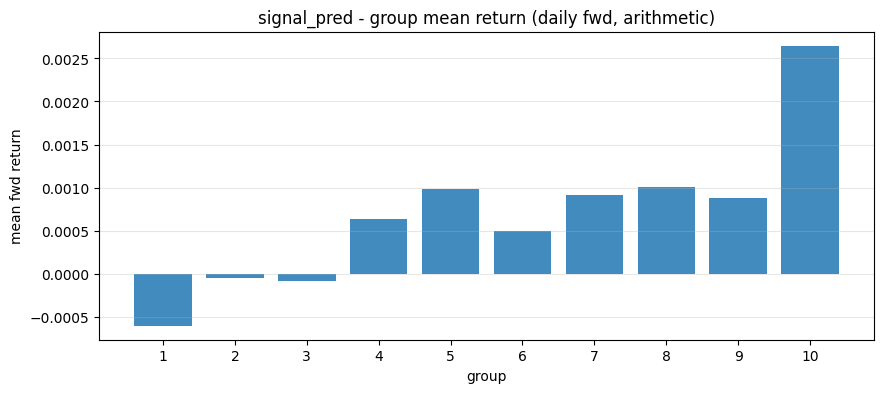

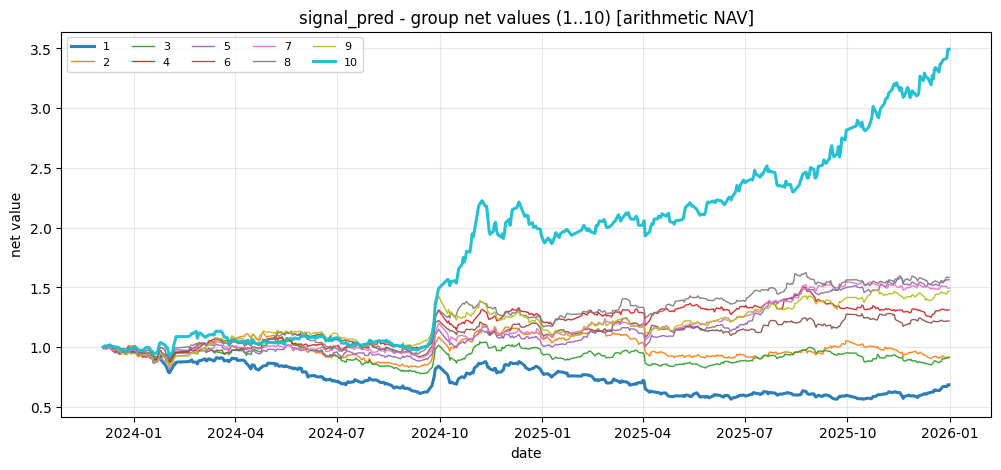

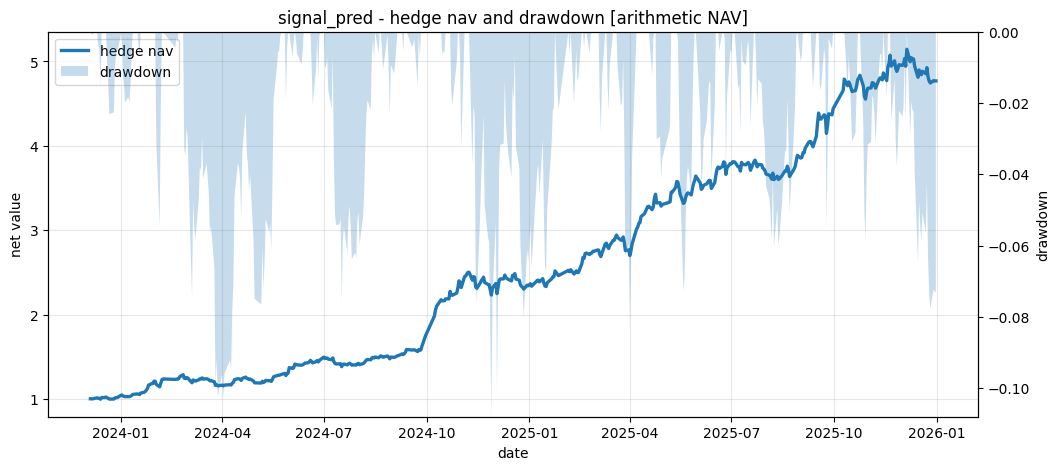

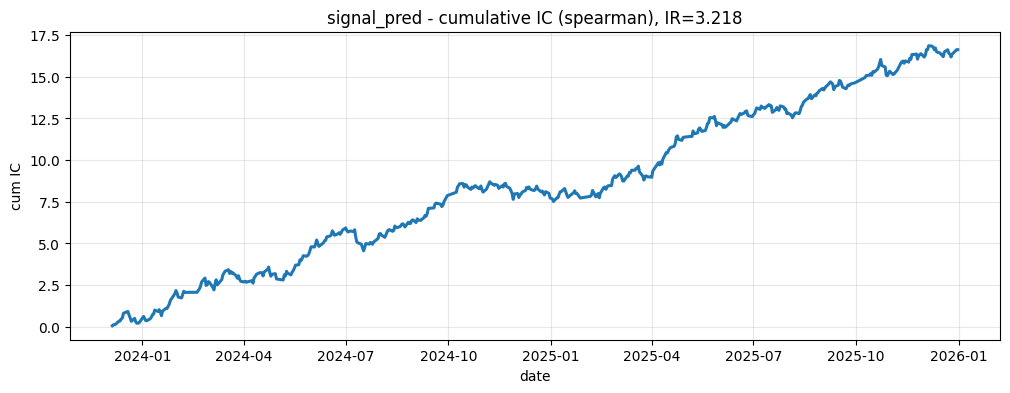

===== Yearly IC (annualized IR) =====
       IC_mean    IC_std     IC_IR  obs
year                                   
2023  0.012523  0.135043  1.472062   19
2024  0.030952  0.161151  3.048983  242
2025  0.036765  0.166453  3.506285  242
    IC_mean    IC_std     IC_IR   avg_ret  hedge_ret_total  annual_ret  \
0  0.033053  0.163067  3.217673  0.003252         3.769026    1.187204   

        MDD        MAR    sharpe  win_ratio  dd_days        dd_start_date  \
0 -0.107992  10.993471  3.044736   0.584493       20  2024-11-08 00:00:00   

           dd_end_date hedge_dir  
0  2024-11-28 00:00:00        HL  
    IC_mean    IC_std     IC_IR   avg_ret  hedge_ret_total  annual_ret  \
0  0.033053  0.163067  3.217673  0.003252         3.769026    1.187204   

        MDD        MAR    sharpe  win_ratio  dd_days        dd_start_date  \
0 -0.107992  10.993471  3.044736   0.584493       20  2024-11-08 00:00:00   

           dd_end_date hedge_dir  
0  2024-11-28 00:00:00        HL  


In [21]:
import numpy as np
import pandas as pd

sig_col = "signal_pred"

# 1) 从原始 df_train 切 test（保证列齐全）
df_te_eval = df_train[df_train["TradingDay"] >= test_start_day].copy()

# 2) 用 X_test 的 index 对齐预测（防止顺序错）
df_te_eval = df_te_eval.loc[X_test.index].copy()
df_te_eval[sig_col] = y_pred

# 3) 强制 dtype
df_te_eval["TradingDay"] = df_te_eval["TradingDay"].astype(int)
df_te_eval["TimeEnd"] = df_te_eval["TimeEnd"].astype(int)

# 4) 日频评估
res_te_day = fast_factor_eval_from_long_df(
    df=df_te_eval,
    close_col="mid",
    factor_col=sig_col,
    asset_col="SecuCode",
    day_col="TradingDay",
    time_col="TimeEnd",
    n_groups=10,
    min_names_per_day=30,
    ic_method="spearman",
    dd_style="fill",
    freq=252,
    is_plot=True,
    use_last_per_day=True,
    hedge_dir="HL",
)

metrics_test_day = res_te_day.get("metrics", res_te_day)
print(metrics_test_day)

C:\Users\Zack66Fair\factor_eval_old.py:112: RuntimeWarning: Mean of empty slice
  return out
C:\Users\Zack66Fair\factor_eval_old.py:113: RuntimeWarning: Mean of empty slice
  


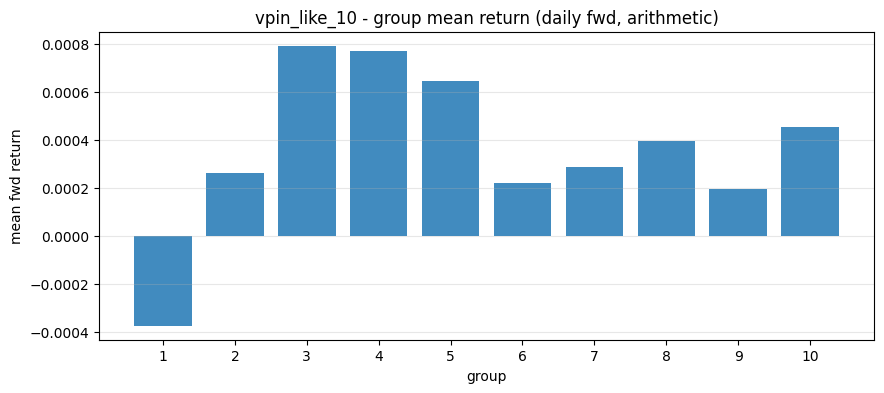

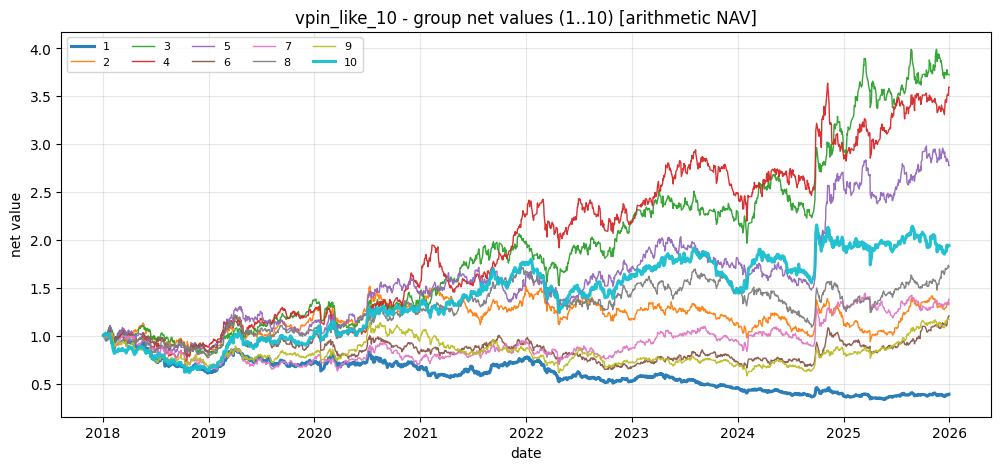

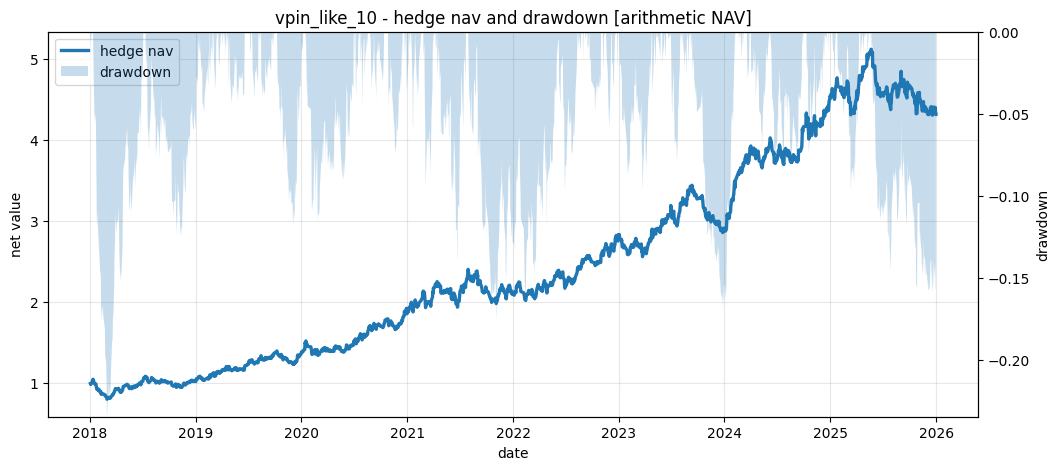

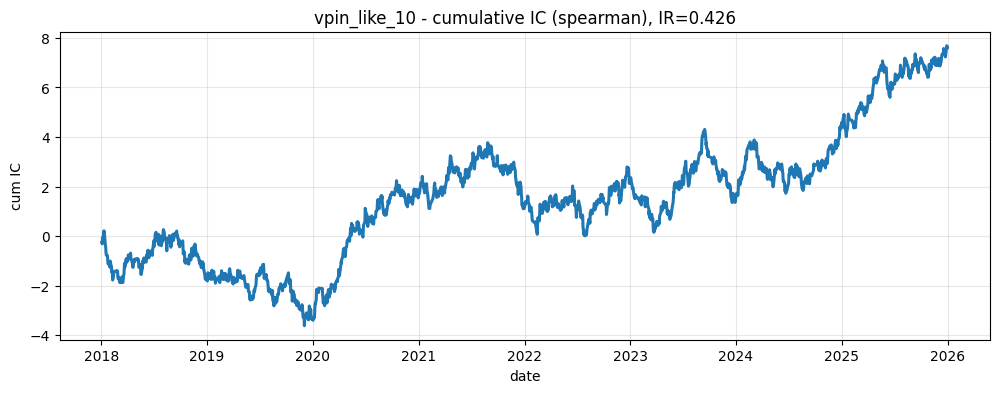

===== Yearly IC (annualized IR) =====
       IC_mean    IC_std     IC_IR  obs
year                                   
2018 -0.007046  0.144020 -0.776593  242
2019 -0.006449  0.140639 -0.727943  244
2020  0.020230  0.145495  2.207195  243
2021 -0.002124  0.150420 -0.224160  243
2022  0.005109  0.153144  0.529604  242
2023 -0.004115  0.147395 -0.443151  242
2024  0.013307  0.144634  1.460559  242
2025  0.012507  0.141518  1.402997  242
    IC_mean    IC_std     IC_IR   avg_ret  hedge_ret_total  annual_ret  \
0  0.003922  0.146322  0.425511  0.000826         3.318577    0.209285   

        MDD       MAR   sharpe  win_ratio  dd_days        dd_start_date  \
0 -0.234684  0.891775  1.09336   0.536082       48  2018-01-12 00:00:00   

           dd_end_date hedge_dir  
0  2018-03-01 00:00:00        HL  


,IC_mean,IC_std,IC_IR,avg_ret,hedge_ret_total,annual_ret,MDD,MAR,sharpe,win_ratio,dd_days,dd_start_date,dd_end_date,hedge_dir
0,0.003922,0.146322,0.425511,0.000826,3.318577,0.209285,-0.234684,0.891775,1.09336,0.536082,48,2018-01-12 00:00:00,2018-03-01 00:00:00,HL


In [298]:
df_day = df_train.copy()
df_day["vpin_like_10"] = -df_day["f_070"]

res_day = fast_factor_eval_from_long_df(
    df=df_day,
    close_col="mid",
    factor_col="vpin_like_10",
    asset_col="SecuCode",
    day_col="TradingDay",
    time_col="TimeEnd",
    n_groups=10,
    min_names_per_day=30,
    ic_method="spearman",
    hedge_dir="HL",     
    ret_clip=None,     
    is_plot=True,
)
res_day["metrics"]

In [21]:
display(res["ic_yearly"], res["metrics"])

,IC_mean,IC_std,IC_IR,obs
year,,,,
2018,0.003157,0.149029,0.336302,243
2019,-0.000050,0.153149,-0.005149,244
2020,-0.033454,0.155352,-3.418464,243
2021,-0.000816,0.148903,-0.087004,243
2022,-0.022291,0.158041,-2.239056,242
2023,0.001552,0.147507,0.166979,242
2024,-0.001602,0.153916,-0.165250,242
2025,-0.005910,0.149402,-0.627951,242


,IC_mean,IC_std,IC_IR,avg_ret,hedge_ret_total,annual_ret,MDD,MAR,sharpe,win_ratio,dd_days,dd_start_date,dd_end_date
0,-0.007424,0.152496,-0.772799,0.000658,1.892129,0.147836,-0.299491,0.493625,0.701493,0.524472,218,2020-08-27 00:00:00,2021-04-02 00:00:00
